In [1]:
# Install necessary libraries
!pip install nibabel tensorflow matplotlib scikit-image

# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage import transform
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, Add, Flatten, Dense, LeakyReLU, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.callbacks import Callback
from IPython.display import clear_output
from google.colab import drive
import random
from tensorflow.keras.regularizers import l2  # Import L2 regularization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, Add, Flatten, Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from IPython.display import clear_output
from tensorflow.keras.regularizers import l2  # Import L2 regularization

from tensorflow.keras.layers import Dropout  # Ensure Dropout is imported

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras import regularizers
from keras.metrics import Precision, Recall


In [ ]:

# List all available GPUs
gpus = tf.config.list_physical_devices('GPU')

# Set TensorFlow to allocate all memory upfront for each GPU
if gpus:
    try:
        for gpu in gpus:
            # Set memory growth to False
            tf.config.experimental.set_memory_growth(gpu, False)
    except RuntimeError as e:
        # This exception is raised when the GPU is already initialized; in this case, memory growth can't be changed.
        print(e)

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
### FOR T2 + FLAIR

# Mount Google Drive
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Data loading and preprocessing functions
def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def preprocess_data(image, resize_target=(300, 300), pad_target=(320, 320)):
    """Normalize, resize, and pad a single slice of MRI data."""
    normalized = image / np.max(image) if np.max(image) > 0 else image
    resized = resize(normalized, resize_target, anti_aliasing=True)
    padded = pad_image_to_size(resized, *pad_target)
    return padded


def pad_image_to_size(image, target_height=320, target_width=320, mode='constant'):
    """Pad the image to the target height and width."""
    current_height, current_width = image.shape[:2]
    delta_h = max(target_height - current_height, 0)
    delta_w = max(target_width - current_width, 0)
    top_pad = delta_h // 2
    bottom_pad = delta_h - top_pad
    left_pad = delta_w // 2
    right_pad = delta_w - delta_w // 2
    padding = ((top_pad, bottom_pad), (left_pad, right_pad))
    padded_image = np.pad(image, padding, mode=mode)
    return padded_image

Mounted at /content/drive


In [ ]:
### MODEL 4 ###

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, AveragePooling2D, Concatenate, GlobalAveragePooling2D, Dense
from tensorflow.keras.regularizers import l2

def conv_block(x, growth_rate, name):
    """A composite function for the Conv2D + BatchNorm + ReLU"""
    x = BatchNormalization(name=name+'_bn')(x)
    x = Activation('relu', name=name+'_relu')(x)
    x = Conv2D(growth_rate, (3, 3), padding='same', kernel_regularizer=l2(0.0005), name=name+'_conv')(x)
    return x

def dense_block(x, num_convs, growth_rate, name_prefix):
    """A dense block where each conv_block's output is concatenated with its input."""
    for i in range(num_convs):
        cb = conv_block(x, growth_rate, name=f"{name_prefix}_block{i+1}")
        x = Concatenate(name=f"{name_prefix}_concat{i+1}")([x, cb])
    return x

def transition_layer(x, reduction, name):
    """A transition layer to reduce the size of the feature map."""
    x = BatchNormalization(name=name+'_bn')(x)
    x = Conv2D(int(tf.keras.backend.int_shape(x)[-1] * reduction), (1, 1), padding='same', kernel_regularizer=l2(0.0005), name=name+'_conv')(x)
    x = AveragePooling2D((2, 2), strides=2, name=name+'_pool')(x)
    return x

def build_densenet(input_shape=(320, 320, 1), num_classes=1, growth_rate=32, num_blocks=[6, 12, 24, 16], reduction=0.5):
    inputs = Input(shape=input_shape, name='input')

    # Initial convolution
    x = Conv2D(growth_rate * 2, (7, 7), strides=2, padding='same', kernel_regularizer=l2(0.0005), name='initial_conv')(inputs)
    x = BatchNormalization(name='initial_bn')(x)
    x = Activation('relu', name='initial_relu')(x)
    x = AveragePooling2D((3, 3), strides=2, padding='same', name='initial_pool')(x)

    # Dense blocks
    for idx, num_conv in enumerate(num_blocks):
        x = dense_block(x, num_conv, growth_rate, name_prefix=f"denseblock{idx+1}")
        if idx != len(num_blocks) - 1:  # no transition layer after the last dense block
            x = transition_layer(x, reduction, name=f"transition{idx+1}")

    # Global Average Pooling and classifier
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    outputs = Dense(num_classes, activation='sigmoid', name='classifier')(x)

    model = Model(inputs=inputs, outputs=outputs, name='DenseNet')
    return model

# Create the DenseNet model
#model = build_densenet()
#model.summary()







In [ ]:
class PlotLosses(Callback):
    def on_train_begin(self, logs=None):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_acc = []
        self.f1s = []
        self.val_f1s = []
        self.logs = []
        self.fig = plt.figure()

    def on_epoch_end(self, epoch, logs=None):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.acc.append(logs.get('accuracy'))
        self.val_acc.append(logs.get('val_accuracy'))

        precision = logs.get('precision')
        recall = logs.get('recall')
        f1 = 2 * (precision * recall) / (precision + recall) if precision is not None and recall is not None and precision + recall > 0 else 0
        self.f1s.append(f1)

        val_precision = logs.get('val_precision')
        val_recall = logs.get('val_recall')
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall) if val_precision is not None and val_recall is not None and val_precision + val_recall > 0 else 0
        self.val_f1s.append(val_f1)

        self.i += 1

        # Plot every 3 epochs
        if self.i % 1 == 0:
            clear_output(wait=True)
            plt.subplot(3, 1, 1)
            plt.plot(self.x, self.losses, label="Training loss")
            plt.plot(self.x, self.val_losses, label="Validation loss")
            plt.legend()
            plt.title('Training and Validation Loss')

            plt.subplot(3, 1, 2)
            plt.plot(self.x, self.acc, label="Training accuracy")
            plt.plot(self.x, self.val_acc, label="Validation accuracy")
            plt.legend()
            plt.title('Training and Validation Accuracy')

            plt.subplot(3, 1, 3)
            plt.plot(self.x, self.f1s, label="Training F1 Score")
            plt.plot(self.x, self.val_f1s, label="Validation F1 Score")
            plt.legend()
            plt.title('Training and Validation F1 Score')

            plt.tight_layout()
            plt.show()


In [ ]:

# Define the early stopping callback
early_stopper = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    min_delta=0.01,      # Minimum change to qualify as an improvement
    patience=10,          # Number of epochs with no improvement after which training will be stopped
    verbose=1,            # Output messages
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

In [ ]:
#### FOR T2+ FLAIR SKIPPPPPPPPPPP IF DATA SAVED

def compile_data(base_path, num_patients):
    """Compile the image data and create binary labels for MS presence."""
    combined_images = []
    ms_labels = []

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii')
        t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-T2.nii')
        seg_flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-Flair.nii')
        seg_t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-T2.nii')

        flair_img = load_nii(flair_path)
        t2_img = load_nii(t2_path)
        ms_flair_img = load_nii(seg_flair_path)
        ms_t2_img = load_nii(seg_t2_path)

        for slice_idx in range(flair_img.shape[2]):
            flair_slice = flair_img[:, :, slice_idx]
            ms_slice = ms_flair_img[:, :, slice_idx]

            flair_processed = preprocess_data(flair_slice)
            combined_images.append(flair_processed)

            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)


        for slice_idx in range(t2_img.shape[2]):
            t2_slice = t2_img[:, :, slice_idx]
            ms_slice = ms_t2_img[:, :, slice_idx]
            t2_processed = preprocess_data(t2_slice)
            combined_images.append(t2_processed)
            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

    X = np.array(combined_images)
    Y = np.array(ms_labels)

    return X, Y

num_patients = 60  # Total number of patients
X, Y = compile_data(base_path, num_patients)

base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/T2_Flair_Data'

# Ensure the directory exists
os.makedirs(base_save_path, exist_ok=True)

# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y.npy'), Y)

In [ ]:
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y.npy'), Y)

NameError: name 'X' is not defined

In [3]:
# Load the saved data
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset'
X = np.load(os.path.join(base_save_path, 'X.npy'))
Y = np.load(os.path.join(base_save_path, 'Y.npy'))

print("Data loaded successfully:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Data loaded successfully:
X shape: (2831, 320, 320)
Y shape: (2831,)


In [4]:
if X.ndim == 3:  # Assuming X.shape is (num_samples, height, width)
    X = np.expand_dims(X, axis=-1)  # Add channel dimension
print("New shape of X:", X.shape)


New shape of X: (2831, 320, 320, 1)


In [ ]:

def check_normalization(data):
    min_val = np.min(data)
    max_val = np.max(data)
    if min_val >= 0 and max_val <= 1:
        print("Data is normalized between 0 and 1.")
        return True
    else:
        print(f"Data is not normalized properly. Min value: {min_val}, Max value: {max_val}")
        return False

# Example usage with your dataset X
is_normalized = check_normalization(X)
# Assuming Y is your array of labels
labels, counts = np.unique(Y, return_counts=True)
print("Label distribution:", dict(zip(labels, counts)))


plt.bar(labels, counts, tick_label=['No MS', 'MS'])
plt.xlabel('Condition')
plt.ylabel('Number of Slices')
plt.title('Distribution of MS in Dataset')
plt.show()


Label distribution: {0: 1401, 1: 1430}


In [5]:
# Now split the data into training+validation (80%) and testing (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

# Split the training and validation set (from the 80% "train_val" split, allocate 20% to validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

print("Adjusted Shape of X_train:", X_train.shape)  # Should be (1698, 320, 320, 1)
print("Adjusted Shape of X_val:", X_val.shape)      # Should be (566, 320, 320, 1)


Adjusted Shape of X_train: (1698, 320, 320, 1)
Adjusted Shape of X_val: (566, 320, 320, 1)


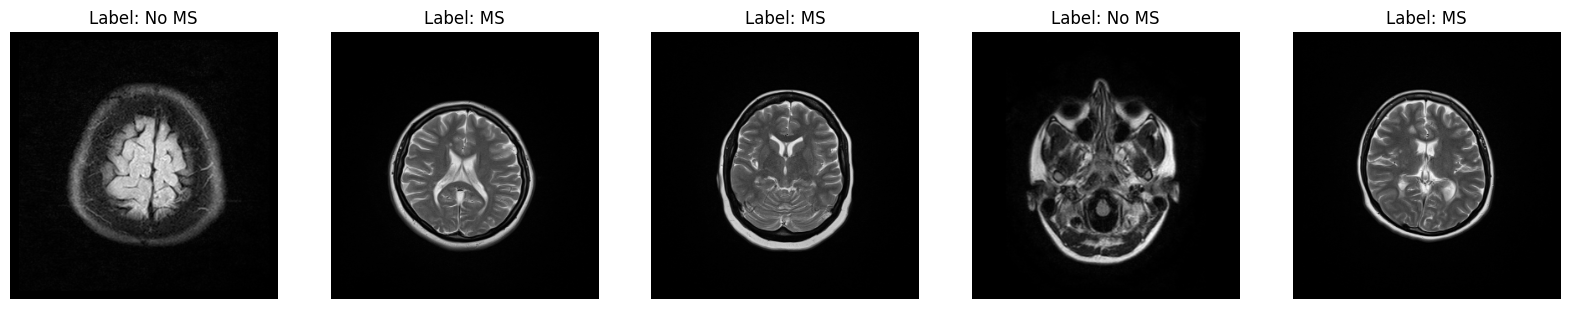

In [ ]:
def visualize_sample_images(X, y, num_samples=5):
    """Randomly visualizes `num_samples` images from dataset `X` with their corresponding labels `y`."""
    indices = np.random.choice(range(len(X)), num_samples, replace=False)
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
    for i, idx in enumerate(indices):
        ax = axes[i]
        ax.imshow(X[idx].squeeze(), cmap='gray')  # Squeeze is used to remove single-dimensional entries from the shape of an array.
        ax.title.set_text(f'Label: {"MS" if y[idx] == 1 else "No MS"}')
        ax.axis('off')
    plt.show()

# Assuming X_train and y_train are your training data and labels loaded into the memory
visualize_sample_images(X_train, y_train)


In [ ]:
# Assuming Y is your array of labels
labels, counts = np.unique(y_test, return_counts=True)
print("Label distribution:", dict(zip(labels, counts)))

Label distribution: {0: 285, 1: 282}


In [ ]:
# Set the seed for NumPy and TensorFlow
np.random.seed(42)
tf.random.set_seed(42)



# Function to adjust the intensity of the image
def adjust_image_intensity_range(img, scale_range=(0.9, 1.1), shift_range=(-0.1, 0.1)):
    scale = np.random.uniform(*scale_range)
    shift = np.random.uniform(*shift_range)
    img = img * scale + shift
    return img

# Function to add random noise to the image
def add_random_noise(img, noise_level=0.05):
    noise = np.random.normal(0, noise_level, img.shape)
    img = img + noise
    return img

# Function to apply motion blur to the image
def apply_motion_blur(img, max_kernel_size=5):
    # Apply horizontal motion blur
    size = np.random.randint(1, max_kernel_size)
    kernel_motion_blur = np.zeros((size, size))
    kernel_motion_blur[int((size-1)/2), :] = np.ones(size)
    kernel_motion_blur = kernel_motion_blur / size
    img = cv2.filter2D(img, -1, kernel_motion_blur)
    return img

# Function to apply affine transformation
def apply_affine_transform(img, intensity=0.1):
    transform_matrix = transform.AffineTransform(scale=(1-intensity, 1-intensity), rotation=np.random.uniform(-intensity, intensity), translation=(img.shape[0]*np.random.uniform(-intensity, intensity), img.shape[1]*np.random.uniform(-intensity, intensity)))
    img = transform.warp(img, transform_matrix)
    return img
import numpy as np
from keras.preprocessing.image import img_to_array, array_to_img

def random_zoom_out(img, original_size=(320, 320), max_scale=1):
    # Choose a random scale factor between the maximum scale and 1 (inclusive)
    scale_factor = np.random.uniform(max_scale, 1.0)
    new_size = (int(original_size[0] * scale_factor), int(original_size[1] * scale_factor))

    # Resize the image
    img = img_to_array(img)  # Ensure it's an array
    img_resized = array_to_img(img).resize(new_size)

    # Convert back to array and pad to original size
    img_resized = img_to_array(img_resized)

    # Calculate padding size
    pad_height = (original_size[0] - new_size[0]) // 2
    pad_width = (original_size[1] - new_size[1]) // 2

    # Pad using 'edge' mode to mimic 'nearest' fill_mode
    img_padded = np.pad(img_resized,
                        ((pad_height, original_size[0] - new_size[0] - pad_height),
                         (pad_width, original_size[1] - new_size[1] - pad_width),
                         (0, 0)),
                        'edge')
    if img_padded.ndim == 2:
        img_padded = np.expand_dims(img_padded, axis=-1)

    return img_padded



def custom_augmentation(img):
    # Define all possible augmentations in a list
    augmentations = [
    adjust_image_intensity_range,
    apply_motion_blur,
    #apply_affine_transform,
    #random_zoom_out
    ]

    # Randomly decide if only one augmentation will be applied (75% chance)
    if np.random.rand() < 0.25: # originally 0.75 now 100% of images will get only 1 data augmentation none will get a combo
        # Choose one augmentation randomly
        augmentation_to_apply = np.random.choice(augmentations, 1)[0]
        img = augmentation_to_apply(img)
    else:
        # Apply a combination of augmentations (25% chance)
        np.random.shuffle(augmentations)  # Shuffle the list of augmentations
        for augmentation in augmentations:
            if np.random.rand() > 0.5:
                img = augmentation(img)

    # Ensure the image has three dimensions
    if img.ndim == 2:
        img = np.expand_dims(img, axis=-1)

    return img



# ImageDataGenerator configuration
train_datagen = ImageDataGenerator(
                rotation_range=30,
    horizontal_flip=True,
    width_shift_range=0.08,
    height_shift_range=0.08,
    fill_mode='nearest',
    preprocessing_function=custom_augmentation  # Unified custom augmentation function
)


val_datagen = ImageDataGenerator()

# Generators
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)


In [ ]:
class PredictionCallback(Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs={}):
        # Predictions on the validation set
        val_preds = self.model.predict(self.validation_data[0])
        # Convert predictions to binary (0 or 1) using 0.5 as a threshold
        val_preds_binary = (val_preds > 0.5).astype(int)
        # Count the number of 0s and 1s
        unique, counts = np.unique(val_preds_binary, return_counts=True)
        prediction_counts = dict(zip(unique, counts))
        print(f'Validation predictions after epoch {epoch+1}: {prediction_counts}')

# When instantiating the callback, pass the validation data
val_data = val_generator.next()
prediction_callback = PredictionCallback(validation_data=val_data)




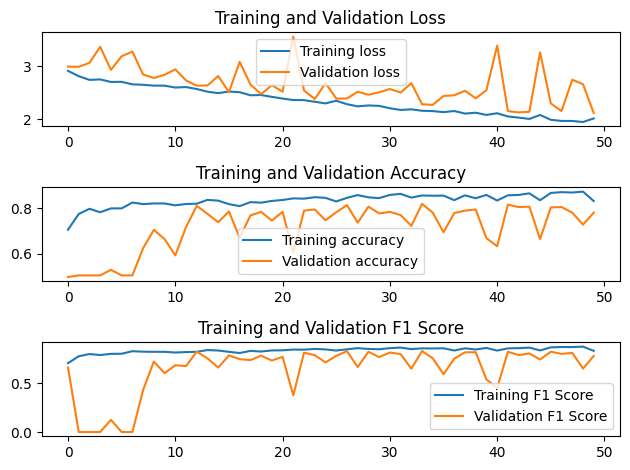

18/18 [==============================] - 2s 103ms/step - loss: 2.1150 - accuracy: 0.7809 - precision: 0.7698 - recall: 0.7972
Evaluate right after training: Loss=2.115043878555298, Accuracy=0.7809187173843384, Precision=0.769759476184845, Recall=0.7971529960632324


In [ ]:
from keras.metrics import Precision, Recall
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, GlobalAveragePooling2D, Dense, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall
plot_losses = PlotLosses()
#model = build_vgg()
model = build_densenet()
model.summary()
#model = build_alexnet()
# model = binary_classification_model()
# Compile the model with precision and recall as metrics
model.compile(optimizer=Adam(learning_rate=0.00005),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# Assuming you have the `train_generator` and `val_generator`
# Fit the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[ early_stopper, plot_losses],
    verbose=1
)

# Evaluate the model
loss, accuracy, precision, recall = model.evaluate(val_generator)
print(f'Evaluate right after training: Loss={loss}, Accuracy={accuracy}, Precision={precision}, Recall={recall}')

from tensorflow.keras.models import load_model
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/My Models'
# Save the arrays
# Define the full path for saving the model
model_save_path = os.path.join(base_save_path, 'DenseNet.keras')

# Save the model
model.save(model_save_path)


In [ ]:
print(f"Early stopping saved model at epoch {best_epoch + 1}")  # +1 because epochs are zero-indexed in the history object
print(f"At this epoch, validation loss was {best_val_loss} and validation accuracy was {best_val_accuracy}")

Early stopping saved model at epoch 46
At this epoch, validation loss was 0.8337721824645996 and validation accuracy was 0.814487636089325


In [ ]:
loss, accuracy, precision, recall = model.evaluate(val_generator)
print(f'Evaluate right after training: Loss={loss}, Accuracy={accuracy}, Precision={precision}, Recall={recall}')


9/9 [==============================] - 1s 124ms/step - loss: 1.0486 - accuracy: 0.7880 - precision: 0.7710 - recall: 0.8149
Evaluate right after training: Loss=1.04864501953125, Accuracy=0.7879858613014221, Precision=0.7710437774658203, Recall=0.8149465918540955


In [ ]:
example_outputs = model.predict(X_val[:])
print(example_outputs)


In [ ]:
model = load_model('DenseNet.h5')

OSError: No file or directory found at DenseNet.h5

In [7]:
# Predict probabilities
pred_probs = model.predict(X_test)

# Convert probabilities to binary classes
pred_classes = (pred_probs >  0.5385714).astype(int)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, pred_classes))

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, pred_classes)
print(conf_matrix)



18/18 [==============================] - 12s 250ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       285
           1       0.82      0.84      0.83       282

    accuracy                           0.83       567
   macro avg       0.83      0.83      0.83       567
weighted avg       0.83      0.83      0.83       567

Confusion Matrix:
[[232  53]
 [ 45 237]]


[0.         0.         0.         0.00350877 0.00350877 0.00701754
 0.00701754 0.01052632 0.01052632 0.01403509 0.01403509 0.01754386
 0.01754386 0.02105263 0.02105263 0.0245614  0.0245614  0.02807018
 0.02807018 0.03157895 0.03157895 0.03508772 0.03508772 0.03859649
 0.03859649 0.04210526 0.04210526 0.04561404 0.04561404 0.05263158
 0.05263158 0.05614035 0.05614035 0.05964912 0.05964912 0.06315789
 0.06315789 0.06666667 0.06666667 0.07017544 0.07017544 0.07719298
 0.07719298 0.08421053 0.08421053 0.0877193  0.0877193  0.09824561
 0.09824561 0.10175439 0.10175439 0.10526316 0.10526316 0.10877193
 0.10877193 0.1122807  0.1122807  0.11578947 0.11578947 0.12280702
 0.12280702 0.13333333 0.13333333 0.14035088 0.14035088 0.14736842
 0.14736842 0.15087719 0.15087719 0.15438596 0.15438596 0.16140351
 0.16140351 0.16491228 0.16491228 0.16842105 0.16842105 0.1754386
 0.1754386  0.17894737 0.17894737 0.18596491 0.18596491 0.19298246
 0.19298246 0.20350877 0.20350877 0.21052632 0.21052632 0.21754

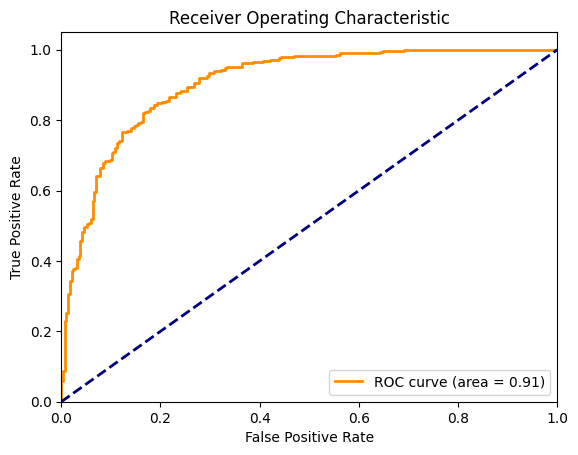

In [8]:
# Import necessary libraries
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
fpr, tpr, thresholds= roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)
print(fpr,tpr)
J = tpr - fpr
# Find the optimal threshold
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold: ", optimal_threshold)
# Plot the ROC curve
import matplotlib.pyplot as plt

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [6]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('/content/drive/My Drive/Semester 10/MS Dataset/My Models/DenseNet.keras')

# Print model summary
model.summary()

Model: "DenseNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 320, 320, 1)]        0         []                            
                                                                                                  
 initial_conv (Conv2D)       (None, 160, 160, 64)         3200      ['input[0][0]']               
                                                                                                  
 initial_bn (BatchNormaliza  (None, 160, 160, 64)         256       ['initial_conv[0][0]']        
 tion)                                                                                            
                                                                                                  
 initial_relu (Activation)   (None, 160, 160, 64)         0         ['initial_bn[0][0]']   

In [ ]:
from tensorflow.keras.utils import plot_model

# Assuming `model` is your AlexNet model
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
def visualize_predictions(X, y, preds, num_samples=20):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples * 5))
    for i in range(num_samples):
        axes[i, 0].imshow(X[i, :, :, 0], cmap='gray')
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(X[i, :, :, 0], cmap='gray')  # Re-displaying the same image for layout consistency
        axes[i, 1].set_title('True Label: {}'.format('MS' if y[i] else 'No MS'))
        axes[i, 1].axis('off')

        axes[i, 2].imshow(X[i, :, :, 0], cmap='gray')  # Re-displaying the same image for layout consistency
        axes[i, 2].set_title('Predicted: {:.2f}% MS'.format(preds[i][0] * 100))
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()

# Predict probabilities
pred_probs = model.predict(X_test)
visualize_predictions(X_test, y_test, pred_probs)
